# Preprocesamiento del Dataset
## Prediccion de Autismo - Pipeline de Imagenes MRI

---

**Objetivo:** Construir el dataset procesado listo para entrenamiento aplicando:

| Paso | Descripcion |
|---|---|
| 1 | Carga del Parquet y extraccion de bytes |
| 2 | Validacion y filtrado de imagenes corruptas |
| 3 | Conversion a RGB + Resize a 224x224 px (LANCZOS) |
| 4 | Data Augmentation (5 variantes por imagen original) |
| 5 | Division estratificada por patient_id (70/15/15) |
| 6 | Guardado en disco con estructura de carpetas por split y clase |

**Clases:** `Autism` / `NonAutism`  
**Nota:** Solo se genera la version **con Data Augmentation**. La division se realiza por `patient_id` para evitar data leakage.

---

## 1. Importaciones y Configuracion Global

In [4]:
import io
import os
import random
import warnings
import time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageEnhance, ImageOps
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm


# Semilla global para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Parametros del pipeline
IMG_SIZE       = (224, 224)
AUGMENT_FACTOR = 5   # variantes generadas por imagen original

# Columnas del dataset
PATIENT_ID_COL = 'patient_id'
LABEL_COL      = 'label'
SLICE_TYPE_COL = 'image_type'
IMAGE_COL      = 'image'

CLASS_NAMES  = ['Autism', 'NonAutism']
SLICE_TYPES  = ['axial', 'coronal', 'sagittal']

# Rutas
DATA_PATH  = Path('../data/data.parquet')
OUT_BASE   = Path('../dataset_procesado')

# Paleta de colores
PALETTE = {
    'autism'    : '#E63946',
    'nonautism' : '#2A9D8F',
    'axial'     : '#457B9D',
    'coronal'   : '#F4A261',
    'sagittal'  : '#8338EC',
}
CLASS_COLORS = {'Autism': PALETTE['autism'], 'NonAutism': PALETTE['nonautism']}

plt.rcParams.update({
    'figure.dpi'        : 120,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
})

print('Configuracion cargada.')
print(f'   Tamano de salida    : {IMG_SIZE}')
print(f'   Factor augmentacion : {AUGMENT_FACTOR}x por imagen')
print(f'   Directorio salida   : {OUT_BASE.resolve()}')

Configuracion cargada.
   Tamano de salida    : (224, 224)
   Factor augmentacion : 5x por imagen
   Directorio salida   : D:\ANTIGRAVITY\proyectos\app_prediccion_autismo_multimodal\dataset_procesado


---
## 2. Carga del Dataset Parquet

In [5]:
print(f'Cargando dataset desde: {DATA_PATH}')
df_raw = pd.read_parquet(DATA_PATH)

# Extraer bytes del formato HuggingFace: {'bytes': b'...'}
df_raw['image_bytes'] = df_raw[IMAGE_COL].apply(
    lambda x: x['bytes'] if isinstance(x, dict) else x
)

print(f'Dataset cargado.')
print(f'   Filas totales  : {len(df_raw):,}')
print(f'   Columnas       : {list(df_raw.columns)}')
print(f'   Clases         : {df_raw[LABEL_COL].unique().tolist()}')
print(f'   Tipos de corte : {df_raw[SLICE_TYPE_COL].unique().tolist()}')
print(f'   Pacientes unicos: {df_raw[PATIENT_ID_COL].nunique():,}')

print('\nDistribucion por clase:')
print(df_raw[LABEL_COL].value_counts().to_string())

df_raw.head()

Cargando dataset desde: ..\data\data.parquet
Dataset cargado.
   Filas totales  : 5,835
   Columnas       : ['image', 'image_type', 'label', 'caption', 'patient_id', 'image_bytes']
   Clases         : ['Autism', 'NonAutism']
   Tipos de corte : ['axial', 'coronal', 'sagittal']
   Pacientes unicos: 1,945

Distribucion por clase:
label
NonAutism    2970
Autism       2865


,image,image_type,label,caption,patient_id,image_bytes
0,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,axial,Autism,A 48-year-old male with an FIQ score of 131 an...,ABIDEII-BNI_1_29006,b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
1,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,coronal,Autism,A 48-year-old male with an FIQ score of 131 an...,ABIDEII-BNI_1_29006,b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
2,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,sagittal,Autism,A 48-year-old male with an FIQ score of 131 an...,ABIDEII-BNI_1_29006,b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
3,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,axial,Autism,A 41-year-old male right-handed patient with a...,ABIDEII-BNI_1_29007,b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
4,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,coronal,Autism,A 41-year-old male right-handed patient with a...,ABIDEII-BNI_1_29007,b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...


---
## 3. Validacion y Filtrado de Imagenes

In [6]:
def validate_image(img_bytes):
    """Intenta abrir la imagen desde bytes y retorna si es valida."""
    try:
        img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
        w, h = img.size
        if w < 10 or h < 10:
            return {'valid': False, 'reason': 'dimensiones_invalidas', 'w': w, 'h': h}
        return {'valid': True, 'reason': None, 'w': w, 'h': h}
    except Exception:
        return {'valid': False, 'reason': 'lectura_fallida', 'w': None, 'h': None}


print('Validando imagenes...')
validations = [validate_image(b) for b in tqdm(df_raw['image_bytes'], desc='Validando')]

df_raw = df_raw.assign(
    valid  = [v['valid']  for v in validations],
    reason = [v['reason'] for v in validations],
    orig_w = [v['w']      for v in validations],
    orig_h = [v['h']      for v in validations],
)

n_total   = len(df_raw)
n_invalid = (~df_raw['valid']).sum()
n_valid   = df_raw['valid'].sum()
df        = df_raw[df_raw['valid']].reset_index(drop=True)

print(f'\nResultado de validacion:')
print(f'   Total    : {n_total:,}')
print(f'   Validas  : {n_valid:,}  ({n_valid/n_total*100:.1f}%)')
print(f'   Invalidas: {n_invalid:,} ({n_invalid/n_total*100:.1f}%)')
if n_invalid > 0:
    print(f'   Causas   :\n{df_raw[~df_raw["valid"]]["reason"].value_counts().to_string()}')

Validando imagenes...


Validando: 100%|██████████| 5835/5835 [00:03<00:00, 1549.80it/s]


Resultado de validacion:
   Total    : 5,835
   Validas  : 5,835  (100.0%)
   Invalidas: 0 (0.0%)


---
## 4. Definicion de Transformaciones

### 4.1 Pipeline Base
Apertura -> RGB -> Resize a 224x224 (LANCZOS)

### 4.2 Data Augmentation

| # | Tecnica | Parametros |
|---|---|---|
| 1 | Flip Horizontal | p = 0.5 |
| 2 | Flip Vertical | p = 0.3 |
| 3 | Rotacion aleatoria | -15 a +15 grados |
| 4 | Brillo | factor en [0.80, 1.25] |
| 5 | Contraste | factor en [0.80, 1.20] |
| 6 | Saturacion (color) | factor en [0.60, 1.40] |
| 7 | Nitidez | factor en [0.0, 2.0] |
| 8 | Random crop + resize (zoom) | 80-100% del area |
| 9 | Ruido Gaussiano suave | sigma en [0, 0.025], p = 0.5 |
| 10 | Traslacion | +-10% en x e y, p = 0.5 |

In [9]:
def preprocess_base(img_bytes):
    """Pipeline base: bytes -> PIL RGB 224x224."""
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
    img = img.resize(IMG_SIZE, Image.LANCZOS)
    return img


def augment_image(img, rng):
    """
    Aplica un conjunto aleatorio de 10 transformaciones sobre una imagen PIL ya
    redimensionada. Retorna PIL.
    """
    # 1. Flip horizontal
    if rng.random() > 0.5:
        img = ImageOps.mirror(img)

    # 2. Flip vertical
    if rng.random() > 0.7:
        img = ImageOps.flip(img)

    # 3. Rotacion aleatoria -15 a +15 grados
    angle = rng.uniform(-15, 15)
    img   = img.rotate(float(angle), resample=Image.BILINEAR, expand=False)

    # 4. Brillo
    img = ImageEnhance.Brightness(img).enhance(float(rng.uniform(0.90, 1.15)))

    # 5. Contraste
    img = ImageEnhance.Contrast(img).enhance(float(rng.uniform(0.85, 1.15)))

    # 6. Saturacion (color)
    img = ImageEnhance.Color(img).enhance(float(rng.uniform(0.80, 1.20)))

    # 7. Nitidez
    img = ImageEnhance.Sharpness(img).enhance(float(rng.uniform(0.0, 2.0)))

    # 8. Random crop + resize (zoom simulado)
    zoom_pct = float(rng.uniform(0.80, 1.0))
    w, h     = img.size
    new_w    = int(w * zoom_pct)
    new_h    = int(h * zoom_pct)
    left     = int(rng.integers(0, w - new_w + 1))
    top      = int(rng.integers(0, h - new_h + 1))
    img      = img.crop((left, top, left + new_w, top + new_h))
    img      = img.resize((w, h), Image.LANCZOS)

    # 9. Ruido Gaussiano suave
    if rng.random() > 0.5:
        arr   = np.array(img, dtype=np.float32) / 255.0
        sigma = float(rng.uniform(0.0, 0.025))
        noise = rng.normal(0, sigma, arr.shape).astype(np.float32)
        arr   = np.clip(arr + noise, 0.0, 1.0)
        img   = Image.fromarray((arr * 255).astype(np.uint8))

    # 10. Traslacion aleatoria
    if rng.random() > 0.5:
        tx  = int(rng.integers(-int(w * 0.10), int(w * 0.10) + 1))
        ty  = int(rng.integers(-int(h * 0.10), int(h * 0.10) + 1))
        img = img.transform(
            img.size, Image.AFFINE,
            (1, 0, -tx, 0, 1, -ty),
            resample=Image.BILINEAR
        )

    return img


print('Pipeline base y transformaciones de augmentacion definidas (10 tecnicas).')

Pipeline base y transformaciones de augmentacion definidas (10 tecnicas).


---
## 5. Verificacion Visual de Augmentaciones

Muestra una imagen original junto con 5 variantes antes de procesar el dataset completo.

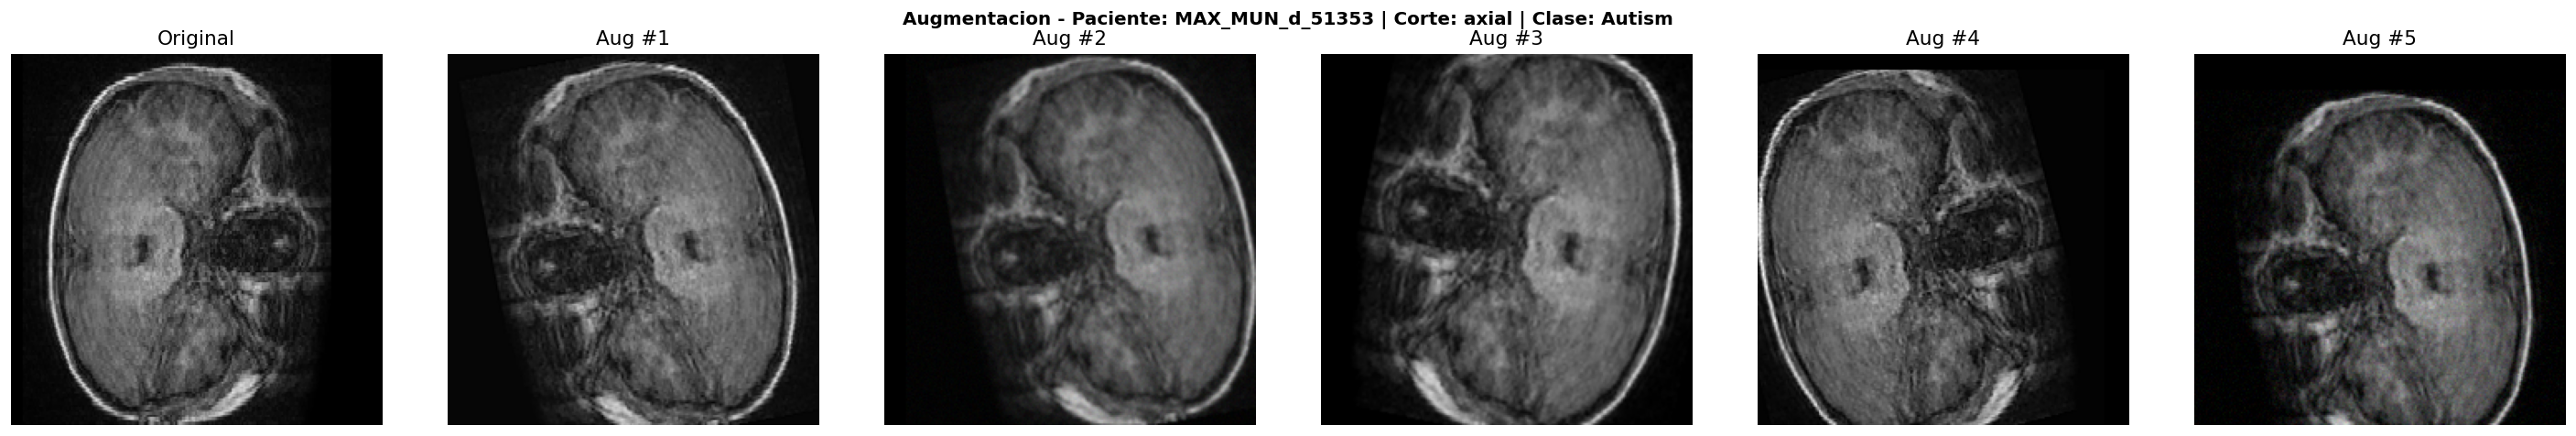

Verificacion visual de augmentaciones completada.


In [10]:
rng_visual = np.random.default_rng(seed=SEED)

# Tomar una muestra de cada clase y tipo de corte
sample_row  = df[df[LABEL_COL] == 'Autism'].sample(1, random_state=SEED).iloc[0]
img_orig    = preprocess_base(sample_row['image_bytes'])

fig, axes = plt.subplots(1, AUGMENT_FACTOR + 1, figsize=(4 * (AUGMENT_FACTOR + 1), 4))
fig.suptitle(
    f'Augmentacion - Paciente: {sample_row[PATIENT_ID_COL]} | '
    f'Corte: {sample_row[SLICE_TYPE_COL]} | Clase: {sample_row[LABEL_COL]}',
    fontsize=12, fontweight='bold'
)

axes[0].imshow(img_orig)
axes[0].set_title('Original')
axes[0].axis('off')

for i in range(1, AUGMENT_FACTOR + 1):
    img_aug = augment_image(img_orig, rng_visual)
    axes[i].imshow(img_aug)
    axes[i].set_title(f'Aug #{i}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()
print('Verificacion visual de augmentaciones completada.')

---
## 6. Verificacion Visual por Tipo de Corte y Clase

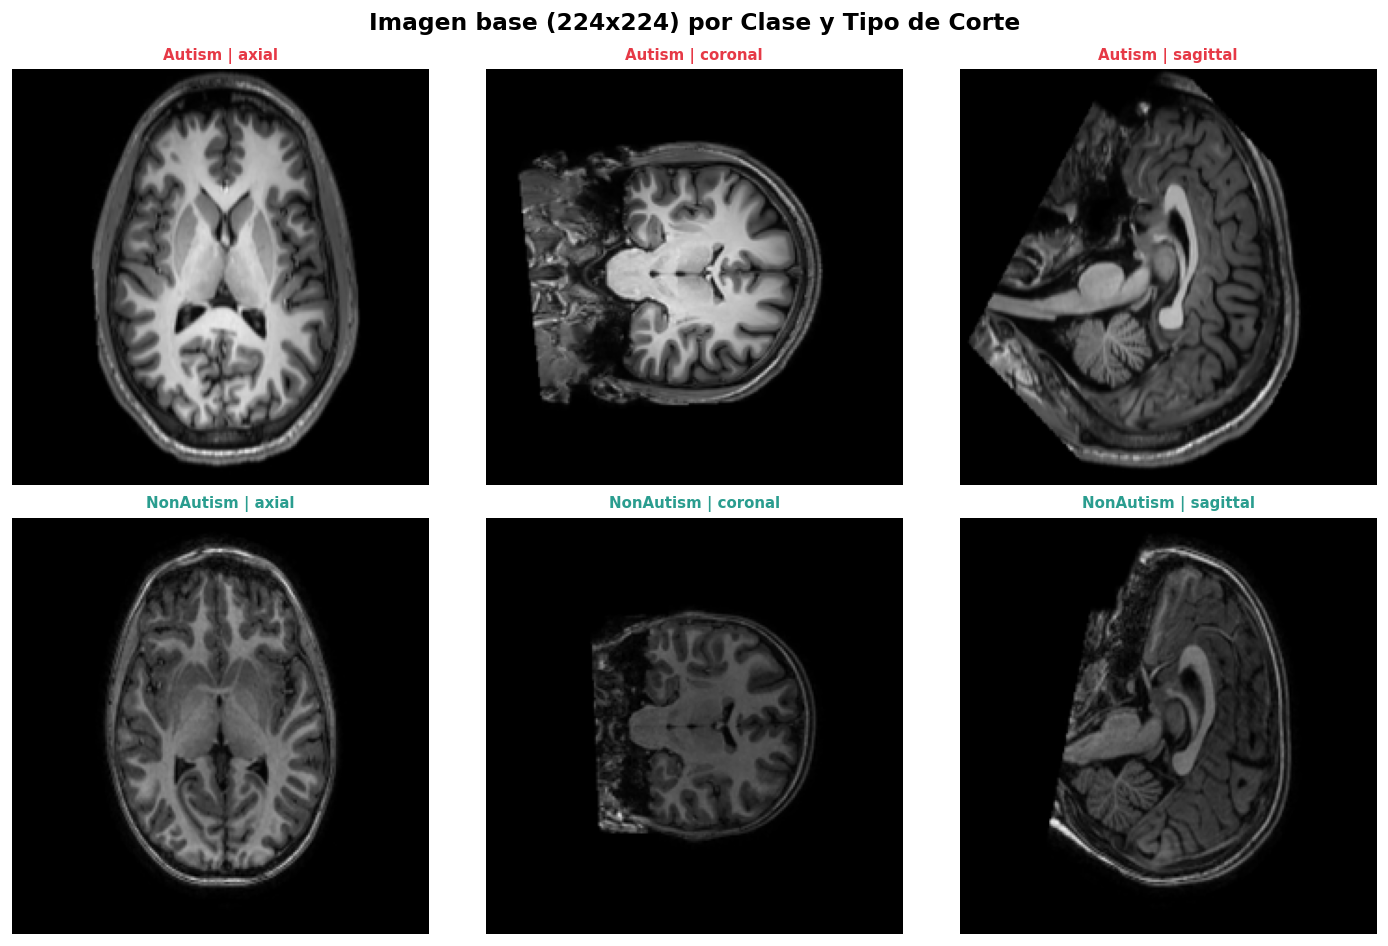

In [11]:
fig, axes = plt.subplots(
    len(CLASS_NAMES), len(SLICE_TYPES),
    figsize=(len(SLICE_TYPES) * 4, len(CLASS_NAMES) * 4)
)
fig.suptitle('Imagen base (224x224) por Clase y Tipo de Corte', fontsize=14, fontweight='bold')

for row_i, cls_name in enumerate(CLASS_NAMES):
    for col_i, st in enumerate(SLICE_TYPES):
        ax     = axes[row_i, col_i]
        subset = df[(df[LABEL_COL] == cls_name) & (df[SLICE_TYPE_COL] == st)]
        if len(subset) == 0:
            ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center')
            ax.axis('off')
            continue
        sample = subset.sample(1, random_state=SEED).iloc[0]
        img    = preprocess_base(sample['image_bytes'])
        ax.imshow(img)
        ax.set_title(f'{cls_name} | {st}', fontsize=9, fontweight='bold',
                     color=CLASS_COLORS.get(cls_name, 'black'))
        for spine in ax.spines.values():
            spine.set_edgecolor(CLASS_COLORS.get(cls_name, 'gray'))
            spine.set_linewidth(3)
            spine.set_visible(True)
        ax.axis('off')

plt.tight_layout()
plt.show()

---
## 7. Division Estratificada por Patient ID (sin Data Leakage)

In [12]:
# Nivel paciente: un paciente = una etiqueta
df_pat_lvl = (
    df.drop_duplicates(subset=[PATIENT_ID_COL])[[PATIENT_ID_COL, LABEL_COL]]
    .reset_index(drop=True)
)

# Conversion explicita a numpy — evita incompatibilidad con ArrowStringArray en sklearn
patient_ids = df_pat_lvl[PATIENT_ID_COL].to_numpy(dtype=str)
labels      = df_pat_lvl[LABEL_COL].to_numpy(dtype=str)

# Split 70 / 15 / 15
ids_train, ids_temp, y_train, y_temp = train_test_split(
    patient_ids, labels, test_size=0.30, stratify=labels, random_state=SEED
)
ids_val, ids_test, y_val, y_test = train_test_split(
    ids_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

# Conjuntos de IDs para asignacion rapida
train_ids_set = set(ids_train)
val_ids_set   = set(ids_val)
test_ids_set  = set(ids_test)

print('Division por Patient ID (sin data leakage):')
print(f'   Train    : {len(ids_train):>5,} pacientes  ({100*len(ids_train)/len(patient_ids):.1f}%)')
print(f'   Valid    : {len(ids_val):>5,} pacientes  ({100*len(ids_val)/len(patient_ids):.1f}%)')
print(f'   Test     : {len(ids_test):>5,} pacientes  ({100*len(ids_test)/len(patient_ids):.1f}%)')

print('\nBalance de clases por split:')
for split_name, ys in [('Train', y_train), ('Valid', y_val), ('Test', y_test)]:
    a = (ys == 'Autism').sum()
    c = (ys == 'NonAutism').sum()
    print(f'   {split_name}: Autism={a}, NonAutism={c}, Ratio={a/max(c,1):.2f}')

print('\nVerificacion anti-leakage:')
print(f'   Train & Val  = {len(train_ids_set & val_ids_set)}  (debe ser 0)')
print(f'   Train & Test = {len(train_ids_set & test_ids_set)} (debe ser 0)')
print(f'   Val   & Test = {len(val_ids_set   & test_ids_set)} (debe ser 0)')

# Guardar splits.csv para referencia
splits_df = pd.DataFrame({
    PATIENT_ID_COL : list(ids_train) + list(ids_val) + list(ids_test),
    'split'        : (['train'] * len(ids_train) +
                      ['val']   * len(ids_val)   +
                      ['test']  * len(ids_test)),
})
splits_path = Path('../data/splits.csv')
splits_path.parent.mkdir(parents=True, exist_ok=True)
splits_df.to_csv(splits_path, index=False)
print(f'\nSplits guardados en: {splits_path}')

Division por Patient ID (sin data leakage):
   Train    : 1,361 pacientes  (70.0%)
   Valid    :   292 pacientes  (15.0%)
   Test     :   292 pacientes  (15.0%)

Balance de clases por split:
   Train: Autism=668, NonAutism=693, Ratio=0.96
   Valid: Autism=143, NonAutism=149, Ratio=0.96
   Test: Autism=144, NonAutism=148, Ratio=0.97

Verificacion anti-leakage:
   Train & Val  = 0  (debe ser 0)
   Train & Test = 0 (debe ser 0)
   Val   & Test = 0 (debe ser 0)

Splits guardados en: ..\data\splits.csv


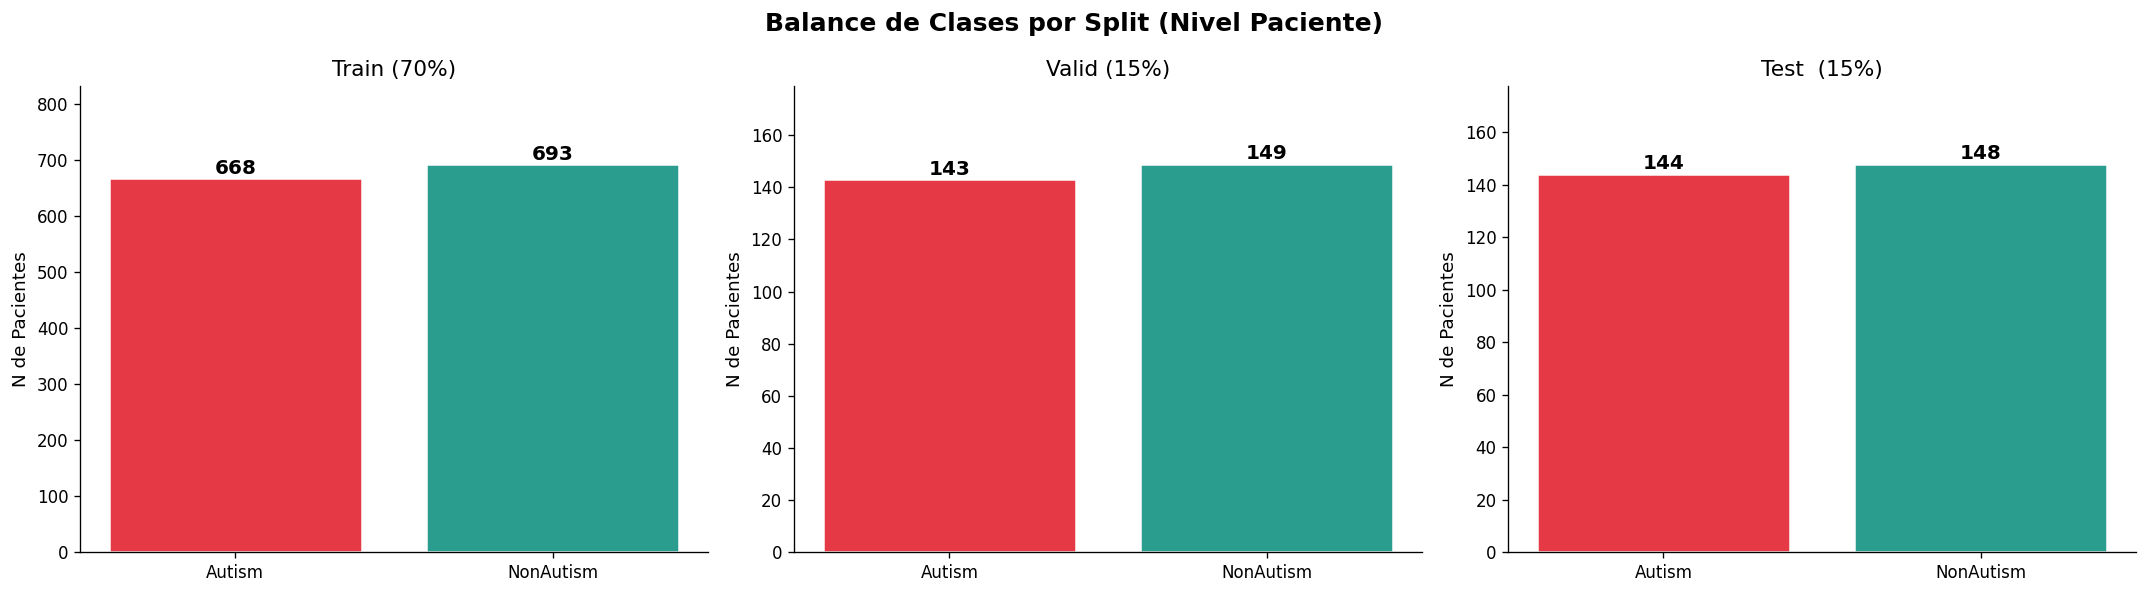

In [13]:
# Grafico de balance de clases por split
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Balance de Clases por Split (Nivel Paciente)',
             fontsize=15, fontweight='bold')

splits_display = [
    ('Train (70%)', y_train),
    ('Valid (15%)', y_val),
    ('Test  (15%)', y_test),
]

for ax, (title, ys) in zip(axes, splits_display):
    a_cnt    = (ys == 'Autism').sum()
    c_cnt    = (ys == 'NonAutism').sum()
    counts_s = [a_cnt, c_cnt]
    labels_s = ['Autism', 'NonAutism']
    colors_s = [CLASS_COLORS['Autism'], CLASS_COLORS['NonAutism']]

    bars = ax.bar(labels_s, counts_s, color=colors_s, edgecolor='white', linewidth=1.5)
    for bar, v in zip(bars, counts_s):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(v), ha='center', va='bottom', fontweight='bold', fontsize=12)
    ax.set_title(title)
    ax.set_ylabel('N de Pacientes')
    ax.set_ylim(0, max(counts_s) * 1.2)

plt.tight_layout()
plt.show()

---
## 8. Procesamiento con Data Augmentation y Guardado en Disco

**Estructura de carpetas generada:**
```
dataset_procesado/
  train/
    Autism/     <- imagen original + AUGMENT_FACTOR variantes
    NonAutism/
  val/
    Autism/     <- solo imagen original (sin augmentacion)
    NonAutism/
  test/
    Autism/     <- solo imagen original (sin augmentacion)
    NonAutism/
```
> **Nota:** La augmentacion se aplica SOLO al conjunto de entrenamiento para evitar sesgo en la evaluacion.

In [14]:
def get_split(patient_id):
    """Retorna 'train', 'val' o 'test' segun el patient_id."""
    if patient_id in train_ids_set:
        return 'train'
    elif patient_id in val_ids_set:
        return 'val'
    else:
        return 'test'


# Crear estructura de carpetas
for split_name in ['train', 'val', 'test']:
    for cls_name in CLASS_NAMES:
        folder = OUT_BASE / split_name / cls_name
        folder.mkdir(parents=True, exist_ok=True)

print(f'Estructura de carpetas creada en: {OUT_BASE.resolve()}')

# Contadores
counters = {'train': {'Autism': 0, 'NonAutism': 0},
            'val'  : {'Autism': 0, 'NonAutism': 0},
            'test' : {'Autism': 0, 'NonAutism': 0}}

errors   = []
rng      = np.random.default_rng(seed=SEED)

t0 = time.time()

for idx, row in tqdm(df.iterrows(), total=len(df), desc='Procesando imagenes'):
    pid       = str(row[PATIENT_ID_COL])
    cls_name  = str(row[LABEL_COL])
    img_bytes = row['image_bytes']
    split     = get_split(pid)

    try:
        img_base = preprocess_base(img_bytes)
    except Exception as e:
        errors.append({'idx': idx, 'pid': pid, 'error': str(e)})
        continue

    # Guardar imagen original
    out_dir  = OUT_BASE / split / cls_name
    out_name = f'{pid}_{row[SLICE_TYPE_COL]}_orig.png'
    img_base.save(out_dir / out_name)
    counters[split][cls_name] += 1

    # Augmentacion SOLO en train
    if split == 'train':
        for aug_i in range(AUGMENT_FACTOR):
            img_aug  = augment_image(img_base, rng)
            aug_name = f'{pid}_{row[SLICE_TYPE_COL]}_aug{aug_i:02d}.png'
            img_aug.save(out_dir / aug_name)
            counters[split][cls_name] += 1

elapsed = time.time() - t0
print(f'\nProcesamiento completado en {elapsed/60:.1f} minutos.')
print(f'Errores encontrados: {len(errors)}')

Estructura de carpetas creada en: D:\ANTIGRAVITY\proyectos\app_prediccion_autismo_multimodal\dataset_procesado


Procesando imagenes: 100%|██████████| 5835/5835 [02:52<00:00, 33.91it/s]


Procesamiento completado en 2.9 minutos.
Errores encontrados: 0


---
## 9. Inventario del Dataset Procesado

In [15]:
print('='*65)
print('          INVENTARIO DEL DATASET PROCESADO')
print('='*65)
total_imagenes = 0
for split_name in ['train', 'val', 'test']:
    subtotal = 0
    print(f'\n  {split_name.upper()}')
    for cls_name in CLASS_NAMES:
        n = counters[split_name][cls_name]
        subtotal += n
        print(f'    {cls_name:<12} : {n:>7,} imagenes')
    print(f'    {"SUBTOTAL":<12} : {subtotal:>7,} imagenes')
    total_imagenes += subtotal

print(f'\n  TOTAL GENERAL    : {total_imagenes:>7,} imagenes')
print('='*65)

# Verificar ratio de augmentacion en train
n_train_orig = int((df[PATIENT_ID_COL].apply(get_split) == 'train').sum())
n_train_total = counters['train']['Autism'] + counters['train']['NonAutism']
if n_train_orig > 0:
    factor_real = n_train_total / n_train_orig
    print(f'\n  Factor de aumento real en train: {factor_real:.1f}x')
    print(f'  (esperado: {AUGMENT_FACTOR + 1:.1f}x = 1 original + {AUGMENT_FACTOR} augmentadas)')

          INVENTARIO DEL DATASET PROCESADO

  TRAIN
    Autism       :  12,024 imagenes
    NonAutism    :  12,474 imagenes
    SUBTOTAL     :  24,498 imagenes

  VAL
    Autism       :     429 imagenes
    NonAutism    :     447 imagenes
    SUBTOTAL     :     876 imagenes

  TEST
    Autism       :     432 imagenes
    NonAutism    :     444 imagenes
    SUBTOTAL     :     876 imagenes

  TOTAL GENERAL    :  26,250 imagenes

  Factor de aumento real en train: 6.0x
  (esperado: 6.0x = 1 original + 5 augmentadas)


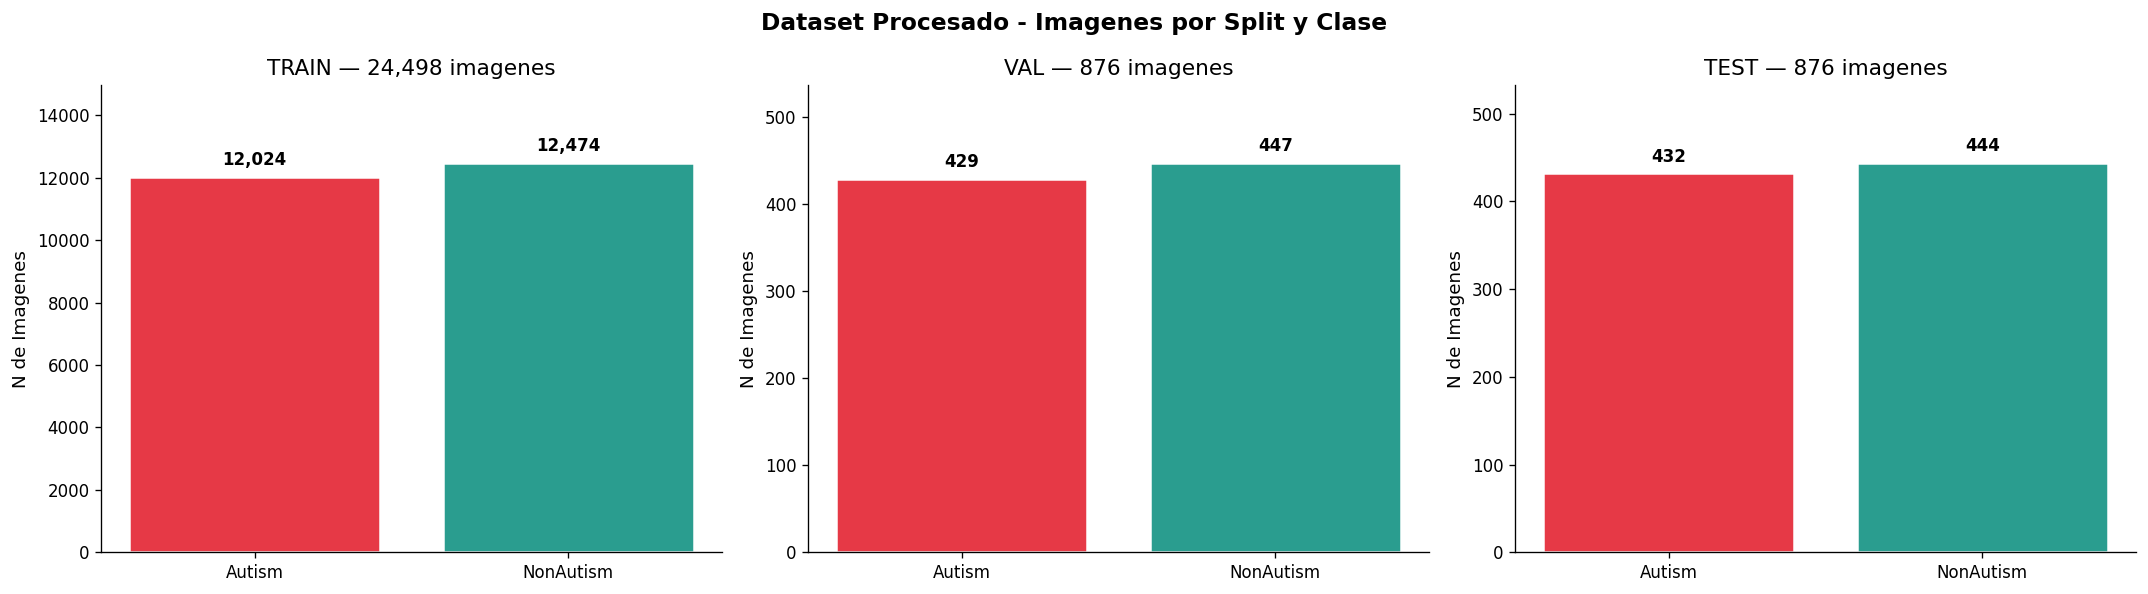

In [16]:
# Grafico resumen del dataset procesado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset Procesado - Imagenes por Split y Clase',
             fontsize=14, fontweight='bold')

for ax, split_name in zip(axes, ['train', 'val', 'test']):
    vals   = [counters[split_name]['Autism'], counters[split_name]['NonAutism']]
    total  = sum(vals)
    colors = [CLASS_COLORS['Autism'], CLASS_COLORS['NonAutism']]
    bars   = ax.bar(CLASS_NAMES, vals, color=colors, edgecolor='white', linewidth=1.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01,
                f'{v:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.set_title(f'{split_name.upper()} — {total:,} imagenes')
    ax.set_ylabel('N de Imagenes')
    ax.set_ylim(0, max(vals) * 1.2 if max(vals) > 0 else 10)

plt.tight_layout()
plt.show()

---
## 10. Verificacion Visual de Imagenes Guardadas

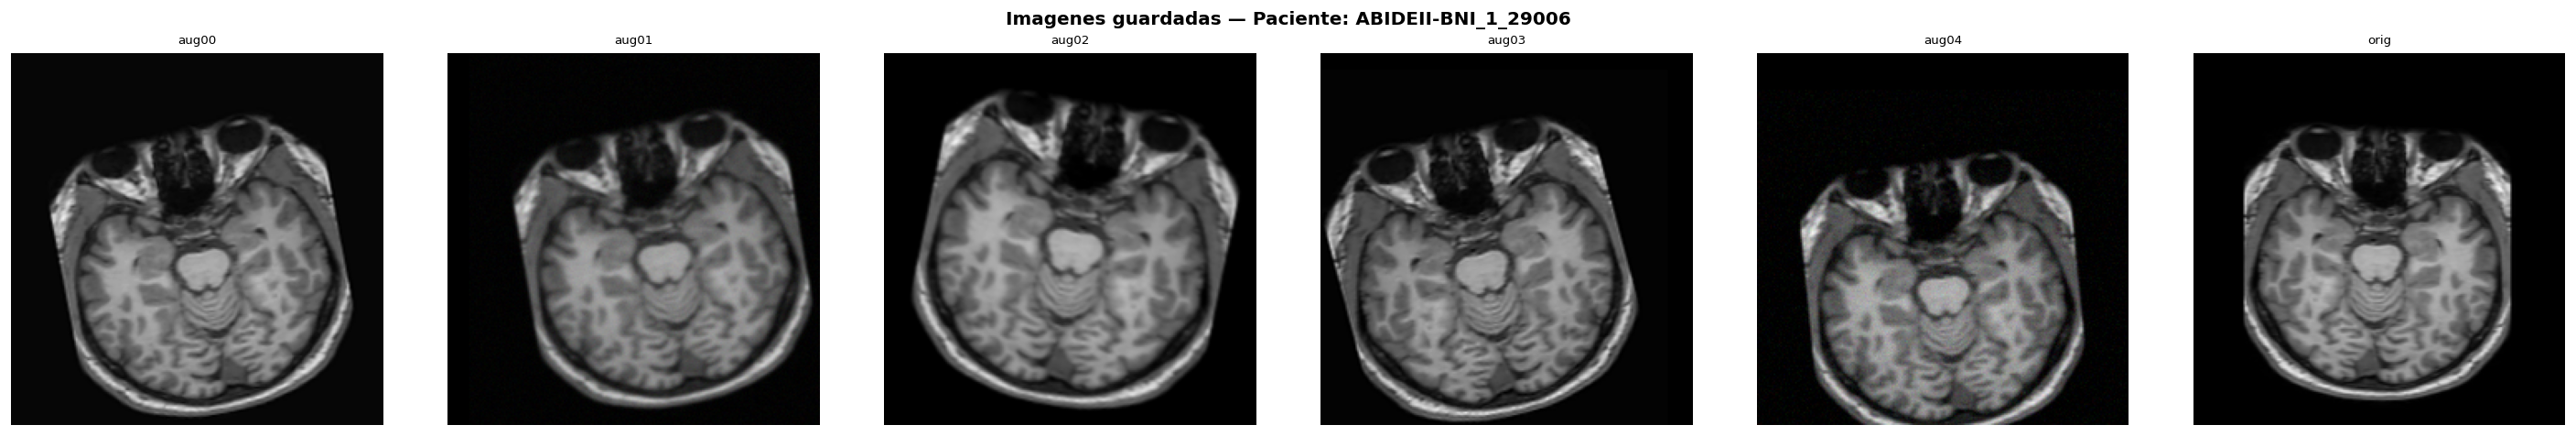

In [17]:
# Mostrar original vs augmentadas de un paciente del train
train_autism_dir = OUT_BASE / 'train' / 'Autism'
sample_files     = sorted(train_autism_dir.glob('*.png'))

if len(sample_files) >= AUGMENT_FACTOR + 1:
    # Tomar las primeras (AUGMENT_FACTOR + 1) imagenes del mismo paciente
    pid_ref     = '_'.join(sample_files[0].stem.split('_')[:-2])
    pat_files   = [f for f in sample_files if f.stem.startswith(pid_ref)]
    pat_files   = pat_files[:AUGMENT_FACTOR + 1]

    fig, axes = plt.subplots(1, len(pat_files), figsize=(4 * len(pat_files), 4))
    if len(pat_files) == 1:
        axes = [axes]
    fig.suptitle(f'Imagenes guardadas — Paciente: {pid_ref}', fontsize=12, fontweight='bold')

    for ax, fpath in zip(axes, pat_files):
        img = Image.open(fpath)
        ax.imshow(img)
        ax.set_title(fpath.stem.split('_')[-1], fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('No hay suficientes imagenes para la verificacion visual. Revisa el paso anterior.')

---
## 11. Resumen Final y Proximos Pasos

In [18]:
print('='*70)
print('     RESUMEN FINAL - PREPROCESAMIENTO COMPLETADO')
print('='*70)
print(f'  Dataset origen      : {DATA_PATH}')
print(f'  Dataset procesado   : {OUT_BASE.resolve()}')
print(f'  Tamano de imagen    : {IMG_SIZE[0]}x{IMG_SIZE[1]} px')
print(f'  Factor augmentacion : {AUGMENT_FACTOR}x (solo train)')
print(f'  Clases              : Autism, NonAutism')
print(f'  Division (pacientes): 70% train / 15% val / 15% test')
print(f'  Anti-leakage        : SI (division por patient_id)')
print('='*70)

total_train = counters['train']['Autism'] + counters['train']['NonAutism']
total_val   = counters['val']['Autism']   + counters['val']['NonAutism']
total_test  = counters['test']['Autism']  + counters['test']['NonAutism']

print(f'  Imagenes Train      : {total_train:>8,} (con augmentacion)')
print(f'  Imagenes Val        : {total_val:>8,} (sin augmentacion)')
print(f'  Imagenes Test       : {total_test:>8,} (sin augmentacion)')
print(f'  Total imagenes      : {total_train + total_val + total_test:>8,}')
print('='*70)

print("""
PROXIMOS PASOS
--------------
1. ENTRENAMIENTO MODELOS BASELINE (ENTRENAMIENTO_MODELOS_POR_CORTE.ipynb):
   - Modelo Axial    : CNN sobre cortes axiales
   - Modelo Coronal  : CNN sobre cortes coronales
   - Modelo Sagittal : CNN sobre cortes sagitales
   - Backbone sugerido: EfficientNetB0 / ResNet18 / MobileNetV2

2. MODELO MULTIMODAL:
   - 3 entradas (axial + coronal + sagittal de un mismo paciente)
   - Fusion de embeddings (concatenacion / attention)
   - Una sola salida de clasificacion binaria (Autism vs NonAutism)

3. METRICAS DE EVALUACION:
   - ROC-AUC (principal)
   - F1-score, Precision, Recall
   - Matriz de confusion
""")

     RESUMEN FINAL - PREPROCESAMIENTO COMPLETADO
  Dataset origen      : ..\data\data.parquet
  Dataset procesado   : D:\ANTIGRAVITY\proyectos\app_prediccion_autismo_multimodal\dataset_procesado
  Tamano de imagen    : 224x224 px
  Factor augmentacion : 5x (solo train)
  Clases              : Autism, NonAutism
  Division (pacientes): 70% train / 15% val / 15% test
  Anti-leakage        : SI (division por patient_id)
  Imagenes Train      :   24,498 (con augmentacion)
  Imagenes Val        :      876 (sin augmentacion)
  Imagenes Test       :      876 (sin augmentacion)
  Total imagenes      :   26,250

PROXIMOS PASOS
--------------
1. ENTRENAMIENTO MODELOS BASELINE (ENTRENAMIENTO_MODELOS_POR_CORTE.ipynb):
   - Modelo Axial    : CNN sobre cortes axiales
   - Modelo Coronal  : CNN sobre cortes coronales
   - Modelo Sagittal : CNN sobre cortes sagitales
   - Backbone sugerido: EfficientNetB0 / ResNet18 / MobileNetV2

2. MODELO MULTIMODAL:
   - 3 entradas (axial + coronal + sagittal de un 

## Generación de Dataset sin Data Augmentation (Base)
A continuación, generamos una versión del dataset dividida con los mismos splits estratificados, pero **sin aplicar data augmentation**. Esto nos servirá para entrenar un modelo baseline y comparar el impacto real de las técnicas de aumento de datos.


In [ ]:
# Configuración de ruta de salida sin DA
OUT_BASE_NO_DA = Path('../data/dataset_procesado_sin_da')

# Crear estructura de carpetas
for split_name in ['train', 'val', 'test']:
    for cls_name in CLASS_NAMES:
        folder = OUT_BASE_NO_DA / split_name / cls_name
        folder.mkdir(parents=True, exist_ok=True)

print(f'Estructura de carpetas sin DA creada en: {OUT_BASE_NO_DA.resolve()}')

# Contadores para el dataset sin DA
counters_no_da = {'train': {'Autism': 0, 'NonAutism': 0},
                  'val'  : {'Autism': 0, 'NonAutism': 0},
                  'test' : {'Autism': 0, 'NonAutism': 0}}

errors_no_da = []
t0_no_da = time.time()

for idx, row in tqdm(df.iterrows(), total=len(df), desc='Procesando imagenes (Sin DA)'):
    pid       = str(row[PATIENT_ID_COL])
    cls_name  = str(row[LABEL_COL])
    img_bytes = row['image_bytes']
    split     = get_split(pid)

    try:
        img_base = preprocess_base(img_bytes)
    except Exception as e:
        errors_no_da.append({'idx': idx, 'pid': pid, 'error': str(e)})
        continue

    # Guardar imagen original (una única por corte)
    out_dir  = OUT_BASE_NO_DA / split / cls_name
    out_name = f'{pid}_{row[SLICE_TYPE_COL]}_orig.png'
    img_base.save(out_dir / out_name)
    counters_no_da[split][cls_name] += 1

elapsed_no_da = time.time() - t0_no_da
print(f'\nProcesamiento (Sin DA) completado en {elapsed_no_da/60:.1f} minutos.')
print(f'Errores encontrados: {len(errors_no_da)}')

print('='*65)
print('          INVENTARIO DEL DATASET SIN DA')
print('='*65)
total_imagenes_no_da = 0
for split_name in ['train', 'val', 'test']:
    subtotal = 0
    print(f'\n  {split_name.upper()}')
    for cls_name in CLASS_NAMES:
        n = counters_no_da[split_name][cls_name]
        subtotal += n
        print(f'    {cls_name:<12} : {n:>7,} imagenes')
    print(f'    {"SUBTOTAL":<12} : {subtotal:>7,} imagenes')
    total_imagenes_no_da += subtotal

print(f'\n  TOTAL GENERAL    : {total_imagenes_no_da:>7,} imagenes')
print('='*65)
